# Phase 7 : Time Series & Forecasting

Ce notebook se concentre sur l'analyse temporelle du chiffre d'affaires (CA) et la prévision des revenus futurs.

## Objectifs :
- Analyser les tendances et saisonnalités du CA.
- Vérifier la stationnarité des données.
- Entraîner des modèles de prévision (ARIMA, SARIMA, Lissage Exponentiel).
- Prédire le CA pour les 30 prochains jours.

## 1. Importation des Bibliothèques et Chargement des Données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Configuration style
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Chargement du dataset
data_path = '../data/processed/dataset_ml_features.csv'
df = pd.read_csv(data_path)

# Nettoyage des dates invalides (remplacer -1, 0 par NaN)
df['FK_Date'] = df['FK_Date'].replace([-1, 0], np.nan)

# Conversion en datetime (les NaN deviennent NaT)
df['Date'] = pd.to_datetime(df['FK_Date'].astype(str), format='%Y%m%d', errors='coerce')

# Supprimer les lignes avec date invalide
initial_len = len(df)
df = df.dropna(subset=['Date']).copy()
print(f"Lignes supprimées (dates invalides) : {initial_len - len(df)}")

# Agrégation journalière du CA (Montant_TTC)
ts_data = df.groupby('Date')['Montant_TTC'].sum().sort_index()
ts_data = ts_data.asfreq('D')  # Assurer une fréquence journalière

print(f"Plage temporelle : {ts_data.index.min()} à {ts_data.index.max()}")
print(f"Nombre de jours : {len(ts_data)}")
ts_data.head()

Lignes supprimées (dates invalides) : 385
Plage temporelle : NaT à NaT
Nombre de jours : 0


Series([], Freq: D, Name: Montant_TTC, dtype: float64)

## 2. Nettoyage et Préparation de la Série

Les séries temporelles nécessitent une continuité. Nous allons vérifier et traiter les valeurs manquantes s'il y a des jours sans ventes.

Lignes initiales : 385
Lignes après suppression des FK_Date <= 0 : 372
Lignes après conversion datetime : 372
Plage : 2023-07-05 00:00:00 à 2026-03-12 00:00:00
Jours avec ventes : 221 sur 982


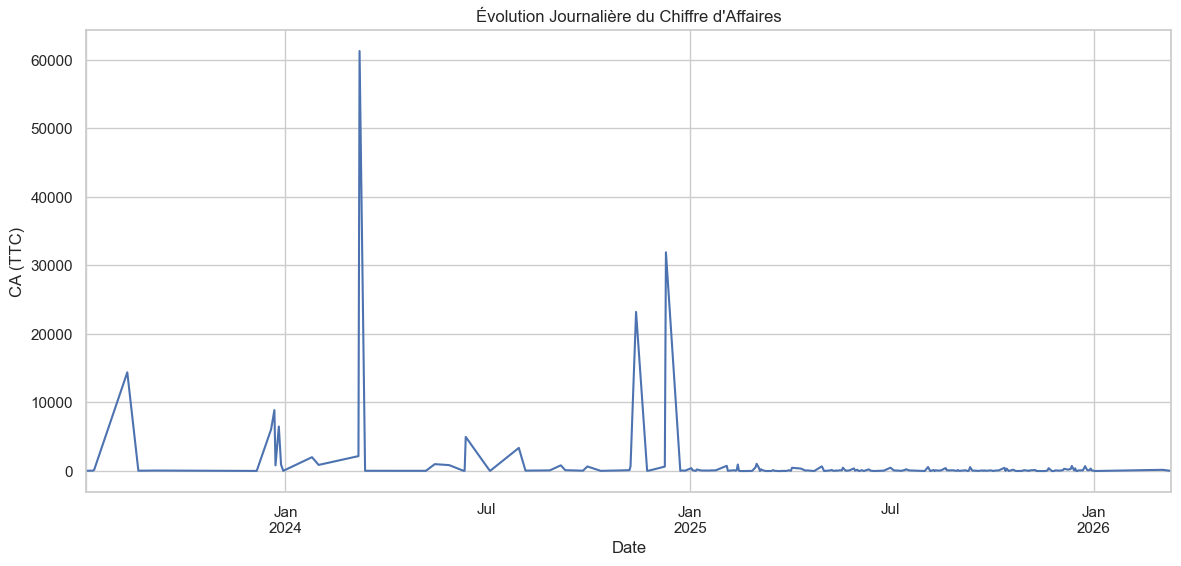

In [6]:
# Chargement du dataset
data_path = '../data/processed/dataset_ml_features.csv'
df = pd.read_csv(data_path)

print(f"Lignes initiales : {len(df)}")

# Filtrer les dates invalides (-1 ou 0)
df = df[df['FK_Date'] > 0].copy()  # Garder seulement les dates positives
print(f"Lignes après suppression des FK_Date <= 0 : {len(df)}")

# Maintenant la colonne FK_Date est de type int (pas de NaN)
df['Date'] = pd.to_datetime(df['FK_Date'].astype(str), format='%Y%m%d', errors='coerce')

# Supprimer les lignes où la conversion a échoué (normalement aucune)
df = df.dropna(subset=['Date']).copy()
print(f"Lignes après conversion datetime : {len(df)}")

if len(df) == 0:
    print("❌ Aucune date valide. Vérifiez le format des FK_Date.")
else:
    # Agrégation journalière
    ts_data = df.groupby('Date')['Montant_TTC'].sum().sort_index()
    ts_data = ts_data.asfreq('D')
    print(f"Plage : {ts_data.index.min()} à {ts_data.index.max()}")
    print(f"Jours avec ventes : {ts_data.notna().sum()} sur {len(ts_data)}")
    
    # Interpolation (seulement si assez de points)
    if ts_data.notna().sum() >= 2:
        ts_data = ts_data.interpolate(method='linear')
        plt.figure(figsize=(14,6))
        ts_data.plot(title='Évolution Journalière du Chiffre d\'Affaires')
        plt.ylabel('CA (TTC)')
        plt.show()
    else:
        print("⚠️ Pas assez de jours avec ventes pour une interpolation fiable.")

## 3. Analyse de la Série : Décomposition et Autocorrélation

Nous allons décomposer la série pour isoler la tendance et la saisonnalité (hebdomadaire par ex).

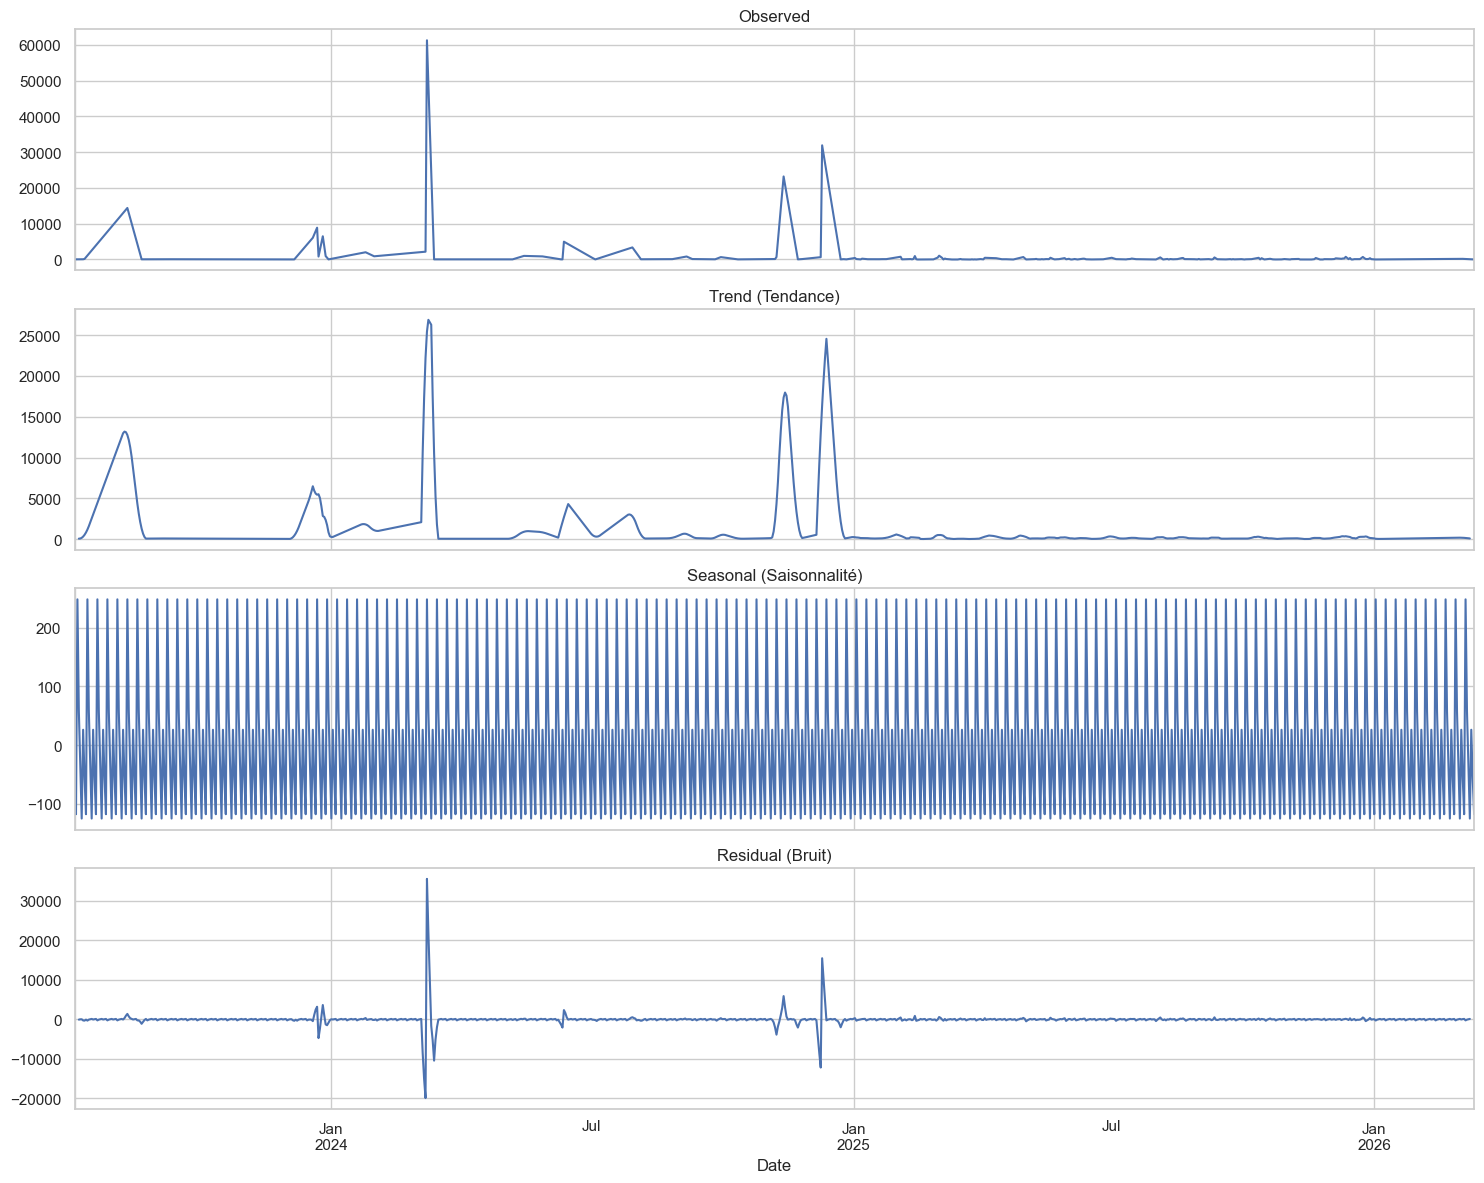

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Décomposition (période 7 pour hebdomadaire)
result = seasonal_decompose(ts_data, model='additive', period=7)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
result.observed.plot(ax=ax1, title='Observed')
result.trend.plot(ax=ax2, title='Trend (Tendance)')
result.seasonal.plot(ax=ax3, title='Seasonal (Saisonnalité)')
result.resid.plot(ax=ax4, title='Residual (Bruit)')
plt.tight_layout()
plt.show()

## 4. Test de Stationnarité (ADF)

Un modèle ARIMA nécessite une série stationnaire (moyenne et variance constantes).

In [8]:
def test_stationarity(timeseries):
    print('Résultats du Test de Dickey-Fuller :')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

test_stationarity(ts_data)

Résultats du Test de Dickey-Fuller :
Test Statistic                -9.603232e+00
p-value                        1.895916e-16
#Lags Used                     2.000000e+00
Number of Observations Used    9.790000e+02
Critical Value (1%)           -3.437047e+00
Critical Value (5%)           -2.864497e+00
Critical Value (10%)          -2.568344e+00
dtype: float64


## 5. Modélisation SARIMA

Nous allons diviser les données en Train/Test et entraîner un modèle SARIMA (Seasonal ARIMA).

Entraînement : 785 jours
Test : 197 jours


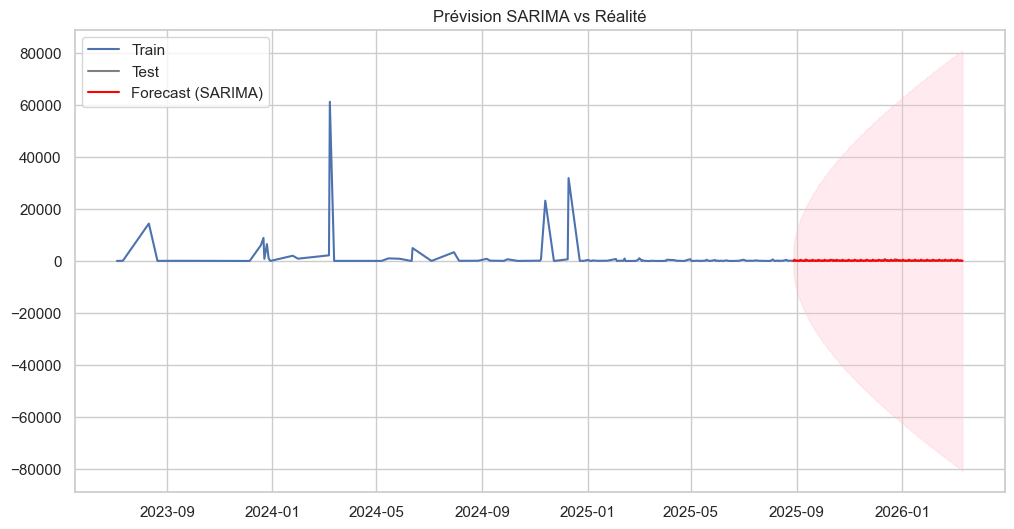

In [9]:
# Split Train/Test (80% / 20% temporel)
train_size = int(len(ts_data) * 0.8)
train, test = ts_data[0:train_size], ts_data[train_size:]

print(f"Entraînement : {len(train)} jours")
print(f"Test : {len(test)} jours")

# Modèle SARIMA (Paramètres simplifiés pour exemple : p,d,q, P,D,Q,s)
# Dans un cas réel, on utiliserait auto_arima pour optimiser p,d,q
import statsmodels.api as sm

model = sm.tsa.statespace.SARIMAX(train, 
                                 order=(1, 1, 1),
                                 seasonal_order=(1, 1, 1, 7))
results = model.fit(disp=False)

# Prédictions sur l'ensemble de test
forecast = results.get_forecast(steps=len(test))
forecast_df = forecast.summary_frame()

plt.figure(figsize=(12, 6))
plt.plot(train, label='Train')
plt.plot(test, label='Test', color='gray')
plt.plot(forecast_df['mean'], label='Forecast (SARIMA)', color='red')
plt.fill_between(forecast_df.index, forecast_df['mean_ci_lower'], forecast_df['mean_ci_upper'], color='pink', alpha=0.3)
plt.legend()
plt.title('Prévision SARIMA vs Réalité')
plt.show()

## 5.2 Modèle 2 : XGBoost pour les Séries Temporelles

Contrairement aux modèles statistiques, XGBoost traite la prévision comme un problème d'apprentissage supervisé. Nous allons créer des variables décalées (lags) pour prédire la valeur suivante.

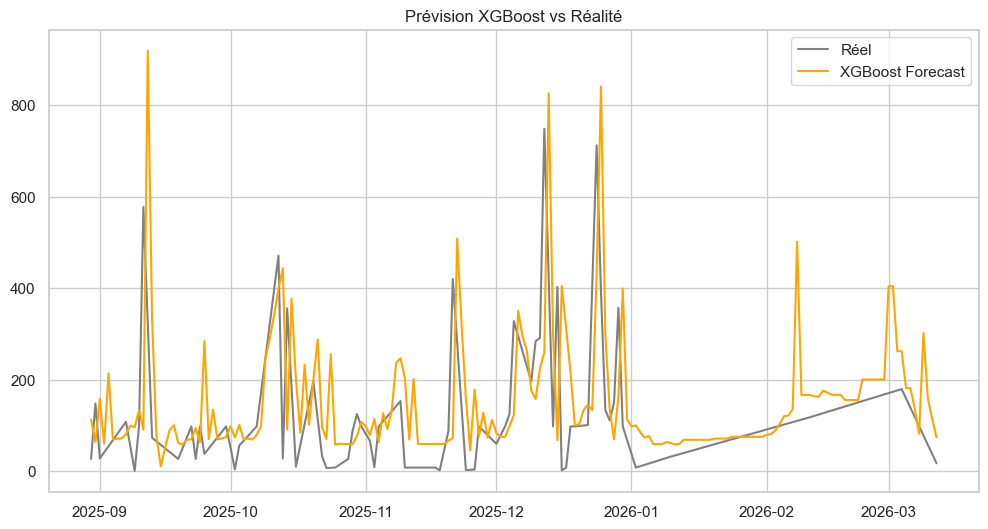

In [10]:
from xgboost import XGBRegressor

def create_lags(data, n_lags=7):
    df_lags = pd.DataFrame(data)
    for i in range(1, n_lags + 1):
        df_lags[f'lag_{i}'] = df_lags['Montant_TTC'].shift(i)
    return df_lags.dropna()

# Préparation des données supervisées (lag de 7 jours pour capturer la saisonnalité hebdo)
df_supervised = create_lags(ts_data.to_frame(), n_lags=7)

X_ts = df_supervised.drop(columns=['Montant_TTC'])
y_ts = df_supervised['Montant_TTC']

# Split temporel (aligné sur le précédent)
split_idx = int(len(df_supervised) * 0.8)
X_train_ts, X_test_ts = X_ts.iloc[:split_idx], X_ts.iloc[split_idx:]
y_train_ts, y_test_ts = y_ts.iloc[:split_idx], y_ts.iloc[split_idx:]

# Entraînement
xgb_ts = XGBRegressor(n_estimators=100, learning_rate=0.05)
xgb_ts.fit(X_train_ts, y_train_ts)

# Prédictions
y_pred_xgb = xgb_ts.predict(X_test_ts)

plt.figure(figsize=(12, 6))
plt.plot(y_test_ts.index, y_test_ts, label='Réel', color='gray')
plt.plot(y_test_ts.index, y_pred_xgb, label='XGBoost Forecast', color='orange')
plt.legend()
plt.title('Prévision XGBoost vs Réalité')
plt.show()

## 5.3 Comparaison des Performances

Comparons SARIMA et XGBoost sur les mêmes données de test.

In [11]:
from sklearn.metrics import mean_absolute_percentage_error

# Métriques SARIMA
mae_s = mean_absolute_error(test, forecast_df['mean'])
rmse_s = np.sqrt(mean_squared_error(test, forecast_df['mean']))
mape_s = mean_absolute_percentage_error(test, forecast_df['mean'])

# Métriques XGBoost (attention aux dates décalées par les lags)
mae_x = mean_absolute_error(y_test_ts, y_pred_xgb)
rmse_x = np.sqrt(mean_squared_error(y_test_ts, y_pred_xgb))
mape_x = mean_absolute_percentage_error(y_test_ts, y_pred_xgb)

summary = pd.DataFrame({
    'Modèle': ['SARIMA', 'XGBoost'],
    'MAE': [mae_s, mae_x],
    'RMSE': [rmse_s, rmse_x],
    'MAPE (%)': [mape_s*100, mape_x*100]
})
summary

,Modèle,MAE,RMSE,MAPE (%)
0,SARIMA,144.336702,195.852003,639.594327
1,XGBoost,80.469095,134.062319,420.752707


## 6. Évaluation

Calcul des erreurs sur le set de test.

In [12]:
from sklearn.metrics import mean_absolute_percentage_error

y_true = test
y_pred = forecast_df['mean']

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape*100:.2f}%")

MAE  : 144.34
RMSE : 195.85
MAPE : 639.59%


## 7. Prévisions Futures (30 jours)

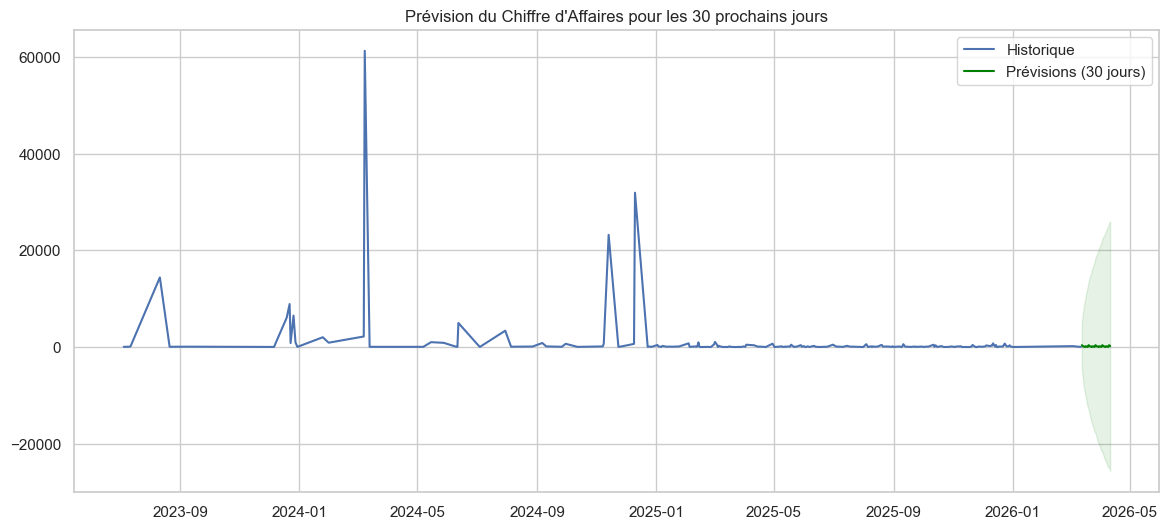

In [13]:
# Entraîner sur toute la donnée disponible pour prédire le futur
final_model = sm.tsa.statespace.SARIMAX(ts_data, 
                                       order=(1, 1, 1),
                                       seasonal_order=(1, 1, 1, 7))
final_results = final_model.fit(disp=False)

# Prévoir 30 jours
future_steps = 30
future_forecast = final_results.get_forecast(steps=future_steps)
future_df = future_forecast.summary_frame()

plt.figure(figsize=(14, 6))
plt.plot(ts_data, label='Historique')
plt.plot(future_df['mean'], label='Prévisions (30 jours)', color='green')
plt.fill_between(future_df.index, future_df['mean_ci_lower'], future_df['mean_ci_upper'], color='green', alpha=0.1)
plt.title('Prévision du Chiffre d\'Affaires pour les 30 prochains jours')
plt.legend()
plt.show()